# Import Packages

In [1]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [2]:
from sklearn import set_config

set_config(transform_output="pandas")

In [3]:
# load the cleaned data

df = pd.read_csv('cleaned_data.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,City_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time,order_hour,order_period,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,Sunny,high,...,24,INDO,Saturday,3,19,1,15.0,11.0,Morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,Stormy,jam,...,33,BANG,Friday,3,25,0,5.0,19.0,Evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,Sandstorms,low,...,26,BANG,Saturday,3,19,1,15.0,8.0,Morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,Sunny,medium,...,21,COIMB,Tuesday,4,5,0,10.0,18.0,Evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,Cloudy,high,...,30,CHEN,Saturday,3,26,1,15.0,13.0,Afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,Windy,high,...,32,JAP,Thursday,3,24,0,10.0,11.0,Morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,Windy,jam,...,36,AGR,Wednesday,2,16,0,15.0,19.0,Evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,Cloudy,low,...,16,CHEN,Friday,3,11,0,15.0,23.0,Night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,Cloudy,high,...,26,COIMB,Monday,3,7,0,5.0,13.0,Afternoon,6.232393


In [4]:
df['distance_type'] = pd.cut(df['distance'],bins=[0,5,10,15,25],
                             right=False,labels=['short','medium','long','very_long'])

In [ ]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'City_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time', 'order_hour',
       'order_period', 'distance', 'distance_type'],
      dtype='object')

In [5]:
df.rename(columns={
    'City_name':'city_name',
    'order_hour':'order_time_hour',
    'order_period':'order_time_of_day',


},inplace=True)

In [6]:
# drop columns not required for model input

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,No,urban,24,1,15.0,Morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,No,metropolitian,33,0,5.0,Evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,No,urban,26,1,15.0,Morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,No,metropolitian,21,0,10.0,Evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,No,metropolitian,30,1,15.0,Afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,No,metropolitian,32,0,10.0,Morning,1.489846,short
45498,21.0,4.6,Windy,jam,0,buffet,motorcycle,1.0,No,metropolitian,36,0,15.0,Evening,NaN,NaN
45499,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,No,metropolitian,16,0,15.0,Night,4.657195,short
45500,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,No,metropolitian,26,0,5.0,Afternoon,6.232393,medium


In [ ]:
# check for missing values

df.isna().sum()

,0
age,912
ratings,945
weather,274
traffic,267
vehicle_condition,1
type_of_order,1
type_of_vehicle,1
multiple_deliveries,492
festival,119
city_type,610


In [7]:
# check for duplicates

df.duplicated().sum()
df.drop_duplicates(inplace=True)

<Axes: >

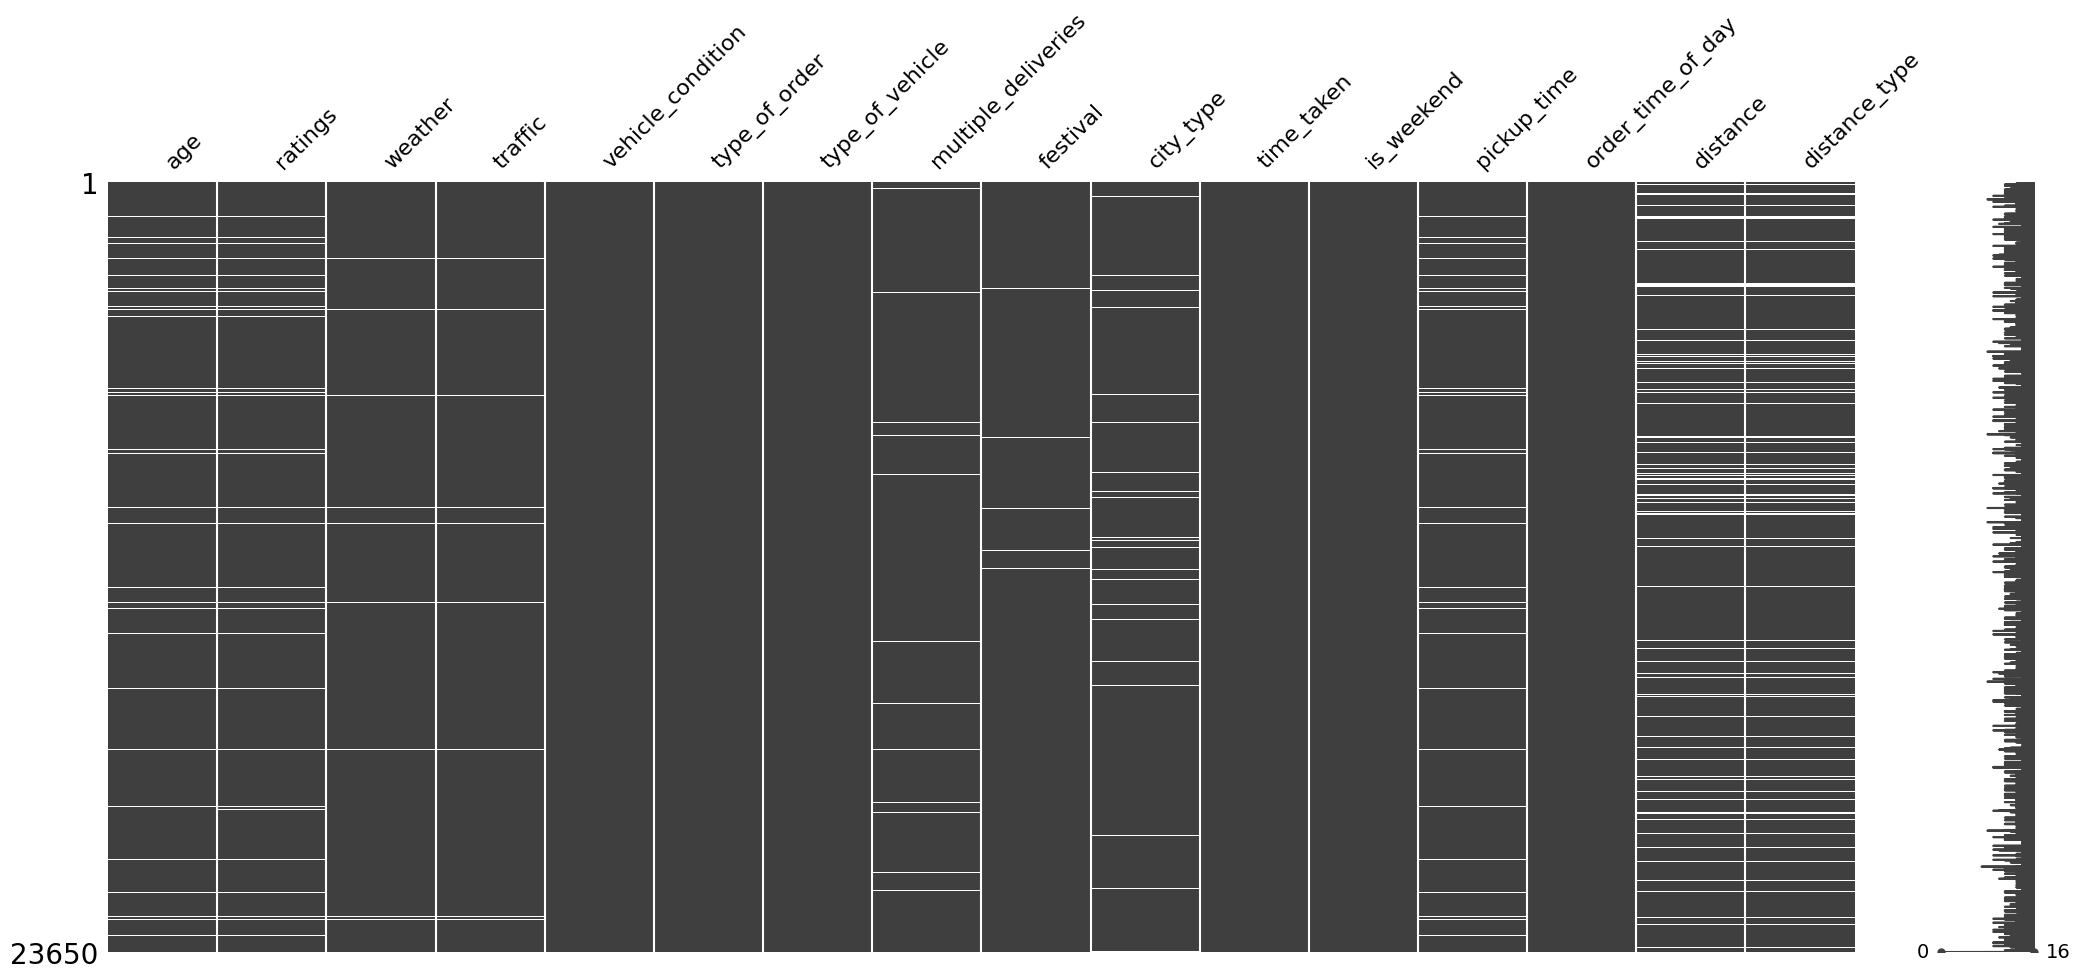

In [ ]:
import missingno as msno

msno.matrix(df)

In [ ]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'is_weekend', 'pickup_time',
       'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

# Drop Missing values

In [8]:
temp_df = df.copy().dropna()

In [9]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,No,urban,1,15.0,Morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,No,metropolitian,0,5.0,Evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,No,urban,1,15.0,Morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,No,metropolitian,0,10.0,Evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,No,metropolitian,1,15.0,Afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,35.0,4.2,Windy,jam,2,drinks,motorcycle,1.0,No,metropolitian,0,10.0,Night,16.600272,very_long
45497,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,No,metropolitian,0,10.0,Morning,1.489846,short
45499,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,No,metropolitian,0,15.0,Night,4.657195,short
45500,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,No,metropolitian,0,5.0,Afternoon,6.232393,medium


In [10]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (15848, 15)
The shape of test data is (3962, 15)


In [ ]:
# missing values in train data

X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [21]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [ ]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'is_weekend', 'pickup_time',
       'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [ ]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


np.float64(0.0)

# Pre Processing Pipeline

In [11]:
num_cols = ["age","ratings","pickup_time","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [12]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [ ]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [ ]:
# # features to fill values with mode

# features_to_fill_mode = ['multiple_deliveries','festival','city_type']
# features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

# features_to_fill_missing

In [ ]:
# # simple imputer to fill categorical vars with mode

# simple_imputer = ColumnTransformer(transformers=[
#     ("mode_imputer",SimpleImputer(strategy="most_frequent",add_indicator=True),features_to_fill_mode),
#     ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing",add_indicator=True),features_to_fill_missing)
# ],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

# simple_imputer

In [ ]:
# simple_imputer.fit_transform(X_train)

In [ ]:
# simple_imputer.fit_transform(X_train).isna().sum()

In [ ]:
# knn imputer

# knn_imputer = KNNImputer(n_neighbors=5)

In [13]:
# do basic preprocessing

num_cols = ["age","ratings","pickup_time","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [14]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [15]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['low' 'high' 'jam' 'medium']
distance_type ['medium', 'very_long', 'long', 'short']
Categories (4, object): ['short' < 'medium' < 'long' < 'very_long']


In [16]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time', 'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [17]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                # ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor)
                                # ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['age', 'ratings',
                                                   'pickup_time', 'distance']),
                                                 ('nominal_encode',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehicle',
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False))])

In [20]:
# do data preprocessing

X_train_trans = processing_pipeline.fit_transform(X_train)

X_test_trans = processing_pipeline.transform(X_test)

In [ ]:
X_train_trans

,age,ratings,pickup_time,distance,weather_Fog,weather_Sandstorms,weather_Stormy,weather_Sunny,weather_Windy,type_of_order_drinks,...,city_type_semi-urban,city_type_urban,is_weekend_1.0,order_time_of_day_Evening,order_time_of_day_Morning,order_time_of_day_Night,traffic,distance_type,vehicle_condition,multiple_deliveries
22608,0.210526,1.00,1.0,0.238700,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
20844,0.842105,0.88,0.5,0.158741,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0
16935,0.736842,0.92,0.5,0.163658,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
8847,0.421053,0.96,0.0,0.324304,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0
3704,0.684211,1.00,1.0,0.003329,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13546,0.210526,0.96,0.5,0.243319,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0
14349,0.631579,0.68,1.0,0.764777,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,0.0,0.0
6512,0.947368,0.92,0.0,0.482063,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,2.0,2.0,1.0
1040,0.105263,0.92,0.0,0.160557,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,1.0,1.0


In [ ]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 19.1 MB/s eta 0:00:00


In [23]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor



In [24]:
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
def objective(trial):
    model_name = trial.suggest_categorical("model", ["SVM", "RF", "KNN", "GB", "XGB", "LGBM"])

    # Define model based on selection
    if model_name == "SVM":
        kernel_svm = trial.suggest_categorical("kernel_svm", ["linear", "poly", "rbf"])
        if kernel_svm == "linear":
            c_linear = trial.suggest_float("c_linear", 0, 10)
            model = SVR(C=c_linear, kernel="linear")
        elif kernel_svm == "poly":
            c_poly = trial.suggest_float("c_poly", 0, 10)
            degree_poly = trial.suggest_int("degree_poly", 1, 5)
            model = SVR(C=c_poly, degree=degree_poly, kernel="poly")
        else:  # rbf
            c_rbf = trial.suggest_float("c_rbf", 0, 100)
            gamma_rbf = trial.suggest_float("gamma_rbf", 0, 10)
            model = SVR(C=c_rbf, gamma=gamma_rbf, kernel="rbf")

    elif model_name == "RF":
        n_estimators_rf = trial.suggest_int("n_estimators_rf", 10, 200)
        max_depth_rf = trial.suggest_int("max_depth_rf", 2, 20)
        model = RandomForestRegressor(
            n_estimators=n_estimators_rf,
            max_depth=max_depth_rf,
            random_state=42,
            n_jobs=-1
        )

    elif model_name == "GB":
        n_estimators_gb = trial.suggest_int("n_estimators_gb", 10, 200)
        learning_rate_gb = trial.suggest_float("learning_rate_gb", 0, 1)
        max_depth_gb = trial.suggest_int("max_depth_gb", 2, 20)
        model = GradientBoostingRegressor(
            n_estimators=n_estimators_gb,
            learning_rate=learning_rate_gb,
            max_depth=max_depth_gb,
            random_state=42
        )

    elif model_name == "KNN":
        n_neighbors_knn = trial.suggest_int("n_neighbors_knn", 1, 25)
        weights_knn = trial.suggest_categorical("weights_knn", ["uniform", "distance"])
        model = KNeighborsRegressor(
            n_neighbors=n_neighbors_knn,
            weights=weights_knn,
            n_jobs=-1
        )

    elif model_name == "XGB":
        n_estimators_xgb = trial.suggest_int("n_estimators_xgb", 10, 200)
        learning_rate_xgb = trial.suggest_float("learning_rate_xgb", 0.1, 0.5)
        max_depth_xgb = trial.suggest_int("max_depth_xgb", 2, 20)
        model = XGBRegressor(
            n_estimators=n_estimators_xgb,
            learning_rate=learning_rate_xgb,
            max_depth=max_depth_xgb,
            random_state=42,
            n_jobs=-1
        )



    # Fit the model
    model.fit(X_train_trans, y_train_pt.values.ravel())

    # Predict
    y_pred_test = model.predict(X_test_trans)

    # Inverse transform
    y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

    # Calculate MAE
    error = mean_absolute_error(y_test, y_pred_test_org)

    return error


In [ ]:
# create optuna study
study = optuna.create_study(direction="minimize", study_name="model_selection")

# optimize the objective function
study.optimize(objective, n_trials=30, n_jobs=-1)

# print the best parameters and score
print("Best parameters:", study.best_params)
print("Best MAE:", study.best_value)


[I 2025-07-01 12:44:39,682] A new study created in memory with name: model_selection
[I 2025-07-01 12:44:40,579] Trial 1 finished with value: 4.471095061633984 and parameters: {'model': 'KNN', 'n_neighbors_knn': 21, 'weights_knn': 'uniform'}. Best is trial 1 with value: 4.471095061633984.
[I 2025-07-01 12:44:45,213] Trial 2 finished with value: 3.2227543852551217 and parameters: {'model': 'RF', 'n_estimators_rf': 67, 'max_depth_rf': 10}. Best is trial 2 with value: 3.2227543852551217.
[I 2025-07-01 12:44:48,164] Trial 3 finished with value: 3.021321779769331 and parameters: {'model': 'LGBM', 'n_estimators_lgbm': 169, 'learning_rate_lgbm': 0.1342466026204955, 'max_depth_lgbm': 15}. Best is trial 3 with value: 3.021321779769331.
[I 2025-07-01 12:45:05,979] Trial 4 finished with value: 3.0036547889575256 and parameters: {'model': 'GB', 'n_estimators_gb': 169, 'learning_rate_gb': 0.04456683952250301, 'max_depth_gb': 9}. Best is trial 4 with value: 3.0036547889575256.
[I 2025-07-01 12:45:43

Best parameters: {'model': 'GB', 'n_estimators_gb': 169, 'learning_rate_gb': 0.04456683952250301, 'max_depth_gb': 9}
Best MAE: 3.0036547889575256


In [19]:
gb_params = {
    "n_estimators": 169,
    "learning_rate": 0.04456683952250301,
    "max_depth": 9
}

In [25]:
# train the model on best parameters

gb = GradientBoostingRegressor(**gb_params)

gb.fit(X_train_trans,y_train_pt.values.ravel())

GradientBoostingRegressor(learning_rate=0.04456683952250301, max_depth=9,
                          n_estimators=169)

In [26]:
# get the predictions
y_pred_train = gb.predict(X_train_trans)
y_pred_test = gb.predict(X_test_trans)

In [27]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [28]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 2.39 minutes
The test error is 3.03 minutes


In [29]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.90
The test r2 score is 0.84


In [32]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gb,
                         X_train_trans,
                         y_train,
                         scoring="r2",
                         cv=5,n_jobs=-1)

scores

array([0.83390342, 0.83580324, 0.83671505, 0.83657264, 0.8298496 ])

In [33]:
# mean score

scores.mean()

np.float64(0.8345687898229859)